In [1]:
# ============================================
# Cell 1: Imports, warnings, plotting setup, and project paths
# Purpose:
# - Load all dependencies required for optimized execution and risk management
# - Keep project paths consistent with the corrected folder structure
# - Prepare plotting for later diagnostics
# ============================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

INITIAL_CAPITAL = 100000.0
SLIPPAGE_BPS = 3.0
TRANSACTION_COST_BPS = 2.0

TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Processed directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed


In [2]:
# ============================================
# Cell 2: Load Phase 6.1 optimized ensemble dataset
# Purpose:
# - Load the optimized ensemble decision layer output
# - Preserve strict time order
# - Confirm the Phase 6.1 file contract before execution logic begins
# ============================================

phase_6_1_parquet = PROCESSED_DIR / "phase_6_1_ensemble_data.parquet"
phase_6_1_csv = PROCESSED_DIR / "phase_6_1_ensemble_data.csv"

print("Looking for Phase 6.1 files:")
print("Parquet:", phase_6_1_parquet)
print("CSV:", phase_6_1_csv)

if phase_6_1_parquet.exists():
    df = pd.read_parquet(phase_6_1_parquet)
    print("Loaded Parquet file")
elif phase_6_1_csv.exists():
    df = pd.read_csv(phase_6_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 6.1 data file was not found. "
        f"Expected one of:\n{phase_6_1_parquet}\n{phase_6_1_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nDataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())

Looking for Phase 6.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_ensemble_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_6_1_ensemble_data.csv
Loaded Parquet file

Dataset shape: (2770, 134)

Dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.380005  203.509995  204.059998     168.990479   
2015-02-05  204.860001  206.300003  204.770004  206.119995     170.696411   
2015-02-06  206.559998  207.240005  204.919998  205.550003     170.224442   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            

In [3]:
# ============================================
# Cell 3: Validation before optimized execution
# Purpose:
# - Confirm required execution inputs exist
# - Prevent silent downstream errors
# - Ensure the optimized data is ready for a realistic capital-path simulation
# ============================================

required_cols = [
    "spy_open",
    "spy_close",
    "target_return_1d",
    "target_return_5d",
    "realized_vol_20",
    "realized_vol_120",
    "atr_pct_14",
    "drawdown_252",
    "ensemble_signal",
    "ensemble_signal_general",
    "ensemble_score",
    "ensemble_confidence",
    "ensemble_regime_label",
    "ensemble_risk_gate",
    "ensemble_risk_penalty",
    "ml_probability_mean",
    "ml_expected_return",
    "quant_risk_filter",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Phase 7.1: {missing_cols}")

assert df.index.is_monotonic_increasing, "Index must be sorted ascending."
assert df.index.duplicated().sum() == 0, "Duplicate timestamps are not allowed."

print("Phase 7.1 validation passed successfully.")

Phase 7.1 validation passed successfully.


In [4]:
# ============================================
# Cell 4: Helper functions for optimized execution and risk management
# Purpose:
# - Centralize sizing, turnover cost, drawdown, and exposure logic
# - Keep the capital path transparent and reproducible
# - Make the optimized execution layer easier to tune later
# ============================================

def min_max_scale_expanding(series: pd.Series, min_periods: int = 60) -> pd.Series:
    exp_min = series.expanding(min_periods=min_periods).min()
    exp_max = series.expanding(min_periods=min_periods).max()

    out = pd.Series(np.nan, index=series.index, dtype=float)
    valid = exp_max > exp_min
    out.loc[valid] = (series.loc[valid] - exp_min.loc[valid]) / (exp_max.loc[valid] - exp_min.loc[valid])

    equal_mask = (exp_max == exp_min) & exp_min.notna()
    out.loc[equal_mask] = 0.5

    return out


def compute_turnover_cost(prev_position: float, new_position: float, total_bps: float) -> float:
    turnover = abs(new_position - prev_position)
    return turnover * (total_bps / 10000.0)


def compute_max_drawdown(equity_curve: pd.Series) -> pd.Series:
    running_peak = equity_curve.cummax()
    return equity_curve / running_peak - 1.0


def bucket_exposure(x: float) -> float:
    if pd.isna(x):
        return 0.0
    if x >= 0.90:
        return 1.00
    if x >= 0.70:
        return 0.75
    if x >= 0.40:
        return 0.50
    if x >= 0.15:
        return 0.25
    return 0.00


def compute_target_exposure(
    ensemble_signal,
    ensemble_score,
    ensemble_confidence,
    regime_label,
    risk_penalty,
    risk_gate,
):
    """
    RETURN-CAPTURE OPTIMIZED EXPOSURE LOGIC
    Philosophy:
    - Default = invested
    - Reduce only when strong negative evidence exists
    """

    if risk_gate == 0:
        return 0.0

    # -----------------------------
    # BASELINE: ALWAYS PARTICIPATE
    # -----------------------------
    base = 0.60   # <- THIS IS THE BIG SHIFT (was near 0 before)

    # -----------------------------
    # UPSIDE BOOST
    # -----------------------------
    if ensemble_signal == 1:
        base += 0.25 * abs(ensemble_score)
        base += 0.15 * ensemble_confidence

    # -----------------------------
    # NEGATIVE SIGNAL (but not zero)
    # -----------------------------
    if ensemble_signal == -1:
        base -= 0.50  # reduce heavily but not always flat

    # -----------------------------
    # REGIME ADJUSTMENT
    # -----------------------------
    if regime_label == "trending":
        base += 0.15

    elif regime_label == "high_volatility":
        base *= 0.50

    elif regime_label == "mean_reverting":
        base *= 0.80

    # -----------------------------
    # RISK PENALTY
    # -----------------------------
    base *= (1.0 - 0.30 * risk_penalty)

    # -----------------------------
    # FINAL CLAMP
    # -----------------------------
    exposure = max(0.0, min(1.0, base))

    # DISCRETIZE
    if exposure >= 0.90:
        return 1.0
    elif exposure >= 0.70:
        return 0.75
    elif exposure >= 0.50:
        return 0.50
    elif exposure >= 0.30:
        return 0.25
    else:
        return 0.0

In [5]:
# ============================================
# Cell 5: Continuous Alpha Allocation (FINAL)
# ============================================

def compute_target_exposure(
    ensemble_score,
    ensemble_confidence,
    ml_expected_return,
    regime_label,
    risk_penalty,
    risk_gate,
):
    """
    CONTINUOUS ALPHA ALLOCATION
    """

    if risk_gate == 0:
        return 0.0

    # ----------------------------------
    # Normalize expected return signal
    # ----------------------------------
    alpha = ml_expected_return

    # Scale alpha (tuneable)
    alpha_scaled = 5.0 * alpha   # <-- IMPORTANT LEVER

    # ----------------------------------
    # Base allocation
    # ----------------------------------
    base = 0.75

    # ----------------------------------
    # Continuous adjustment
    # ----------------------------------
    base += alpha_scaled
    base += 0.25 * ensemble_score
    base += 0.15 * ensemble_confidence

    # ----------------------------------
    # Regime adjustments
    # ----------------------------------
    if regime_label == "trending":
        base += 0.15
    elif regime_label == "high_volatility":
        base *= 0.65
    elif regime_label == "mean_reverting":
        base *= 0.85

    # ----------------------------------
    # Risk penalty
    # ----------------------------------
    base *= (1.0 - 0.30 * risk_penalty)

    # ----------------------------------
    # Clamp (allow slight leverage)
    # ----------------------------------
    exposure = max(0.0, min(1.25, base))

    return exposure


exec_df = df.copy()

exec_df["target_exposure_base"] = 0.0

for dt in exec_df.index:
    exec_df.loc[dt, "target_exposure_base"] = compute_target_exposure(

        ensemble_score=float(exec_df.loc[dt, "ensemble_score"])
        if pd.notna(exec_df.loc[dt, "ensemble_score"]) else 0.0,

        ensemble_confidence=float(exec_df.loc[dt, "ensemble_confidence"])
        if pd.notna(exec_df.loc[dt, "ensemble_confidence"]) else 0.0,

        ml_expected_return=float(exec_df.loc[dt, "ml_expected_return"])
        if pd.notna(exec_df.loc[dt, "ml_expected_return"]) else 0.0,

        regime_label=str(exec_df.loc[dt, "ensemble_regime_label"])
        if pd.notna(exec_df.loc[dt, "ensemble_regime_label"]) else "unknown",

        risk_penalty=float(exec_df.loc[dt, "ensemble_risk_penalty"])
        if pd.notna(exec_df.loc[dt, "ensemble_risk_penalty"]) else 0.5,

        risk_gate=int(exec_df.loc[dt, "ensemble_risk_gate"])
        if pd.notna(exec_df.loc[dt, "ensemble_risk_gate"]) else 0,
    )

print("Continuous alpha-based exposure created.")
print(exec_df[["target_exposure_base"]].head(20))

Continuous alpha-based exposure created.
            target_exposure_base
Date                            
2015-02-02                   0.0
2015-02-03                   0.0
2015-02-04                   0.0
2015-02-05                   0.0
2015-02-06                   0.0
2015-02-09                   0.0
2015-02-10                   0.0
2015-02-11                   0.0
2015-02-12                   0.0
2015-02-13                   0.0
2015-02-17                   0.0
2015-02-18                   0.0
2015-02-19                   0.0
2015-02-20                   0.0
2015-02-23                   0.0
2015-02-24                   0.0
2015-02-25                   0.0
2015-02-26                   0.0
2015-02-27                   0.0
2015-03-02                   0.0


In [6]:
# ============================================
# Cell 6: Hostile-regime caps and drawdown guardrail setup
# Purpose:
# - Add extra safety without crushing market participation
# - Cap exposure in explicitly hostile regimes instead of forcing full exit too early
# - Prepare exposure series for next-day execution
# ============================================

exec_df["execution_target_exposure"] = exec_df["target_exposure_base"].copy()
exec_df["execution_drawdown_guard_flag"] = 0
exec_df["execution_hostile_regime_flag"] = 0

# High-volatility regime cap
high_vol_mask = exec_df["ensemble_regime_label"].eq("high_volatility")
exec_df.loc[high_vol_mask, "execution_hostile_regime_flag"] = 1
exec_df.loc[high_vol_mask, "execution_target_exposure"] = np.minimum(
    exec_df.loc[high_vol_mask, "execution_target_exposure"],
    0.50
)

# Explicit sell / strong negative score -> flat
exec_df.loc[exec_df["ensemble_signal_general"] == -1, "execution_target_exposure"] = 0.00

print("Risk-adjusted optimized target exposure created.")
print(
    exec_df[
        [
            "ensemble_regime_label",
            "ensemble_signal_general",
            "target_exposure_base",
            "execution_target_exposure",
            "execution_hostile_regime_flag",
        ]
    ].head(20)
)

Risk-adjusted optimized target exposure created.
           ensemble_regime_label  ensemble_signal_general  \
Date                                                        
2015-02-02        mean_reverting                        0   
2015-02-03        mean_reverting                        0   
2015-02-04              trending                        1   
2015-02-05        mean_reverting                        0   
2015-02-06              trending                        1   
2015-02-09              trending                        1   
2015-02-10              trending                        1   
2015-02-11              trending                        1   
2015-02-12              trending                        1   
2015-02-13              trending                        1   
2015-02-17              trending                        1   
2015-02-18              trending                        1   
2015-02-19              trending                        1   
2015-02-20              trending    

In [7]:
# ============================================
# Cell 7: Next-day open optimized execution backtest with trend holding logic
# Purpose:
# - Convert optimized target exposure into a realistic capital path
# - Apply next-day open execution timing
# - Include slippage and transaction costs
# - Add trend holding persistence so the strategy does not exit too quickly
# - Reduce whipsaw behavior and improve return capture during strong trends
# ============================================

backtest_df = exec_df.copy()

print("Backtest rows:", len(backtest_df))
print("Execution target exposure non-null rows:", int(backtest_df["execution_target_exposure"].notna().sum()))

# Signal at t becomes executed exposure target at t+1
backtest_df["executed_exposure_target"] = backtest_df["execution_target_exposure"].shift(1).fillna(0.0)

# Open-to-open return approximation
backtest_df["open_to_open_return"] = backtest_df["spy_open"].pct_change().fillna(0.0)

positions = []
costs = []
strategy_returns = []
equity_values = []
drawdown_flags = []
holding_days_list = []

prev_exposure = 0.0
equity = INITIAL_CAPITAL
running_peak = INITIAL_CAPITAL
holding_days = 0

MIN_HOLD_DAYS = 5

for dt, row in backtest_df.iterrows():
    target_exposure = float(row["executed_exposure_target"]) if pd.notna(row["executed_exposure_target"]) else 0.0

    current_drawdown = (equity / running_peak - 1.0) if running_peak > 0 else 0.0
    drawdown_flag = 0

    # ============================================
    # Trend holding logic
    # Purpose:
    # - If already in a position, do not exit too quickly
    # - Only allow fast reduction when there is strong negative evidence
    # - Otherwise decay slowly or maintain exposure
    # ============================================

    if prev_exposure > 0:
        strong_negative_exit = (
            (pd.notna(row["ensemble_signal_general"])) and
            (int(row["ensemble_signal_general"]) == -1) and
            (pd.notna(row["ensemble_score"])) and
            (float(row["ensemble_score"]) < -0.15)
        )

        if strong_negative_exit:
            current_exposure = target_exposure
            holding_days = 0 if current_exposure == 0 else holding_days + 1
        else:
            # Keep exposure sticky to ride trends
            current_exposure = max(prev_exposure * 0.90, target_exposure)

            # Minimum hold period to reduce churn
            if holding_days < MIN_HOLD_DAYS:
                current_exposure = max(current_exposure, prev_exposure)

            holding_days += 1
    else:
        current_exposure = target_exposure
        holding_days = 1 if current_exposure > 0 else 0

    # ============================================
    # Drawdown controls
    # Purpose:
    # - Keep capital protection, but do not overreact too early
    # ============================================

    if current_drawdown <= -0.12:
        current_exposure = min(current_exposure, 0.75)
        drawdown_flag = 1

    if current_drawdown <= -0.18:
        current_exposure = min(current_exposure, 0.50)
        drawdown_flag = 1

    if current_drawdown <= -0.25:
        current_exposure = 0.0
        drawdown_flag = 1
        holding_days = 0

    # Safety clamp
    current_exposure = min(max(current_exposure, 0.0), 1.0)

    # Transaction cost based on exposure turnover
    total_cost = compute_turnover_cost(
        prev_position=prev_exposure,
        new_position=current_exposure,
        total_bps=SLIPPAGE_BPS + TRANSACTION_COST_BPS,
    )

    gross_ret = float(row["open_to_open_return"]) if pd.notna(row["open_to_open_return"]) else 0.0
    strategy_ret = current_exposure * gross_ret - total_cost

    equity = equity * (1.0 + strategy_ret)
    running_peak = max(running_peak, equity)

    positions.append(current_exposure)
    costs.append(total_cost)
    strategy_returns.append(strategy_ret)
    equity_values.append(equity)
    drawdown_flags.append(drawdown_flag)
    holding_days_list.append(holding_days)

    prev_exposure = current_exposure

backtest_df["executed_exposure"] = positions
backtest_df["execution_cost"] = costs
backtest_df["strategy_return"] = strategy_returns
backtest_df["strategy_equity"] = equity_values
backtest_df["execution_drawdown_guard_flag"] = drawdown_flags
backtest_df["holding_days"] = holding_days_list

backtest_df["buy_hold_return"] = backtest_df["open_to_open_return"]
backtest_df["buy_hold_equity"] = INITIAL_CAPITAL * (1.0 + backtest_df["buy_hold_return"]).cumprod()

print("Optimized execution backtest with trend holding logic created successfully.")
print(
    backtest_df[
        [
            "executed_exposure_target",
            "executed_exposure",
            "holding_days",
            "execution_cost",
            "strategy_return",
            "strategy_equity",
        ]
    ].head(20)
)

Backtest rows: 2770
Execution target exposure non-null rows: 2770
Optimized execution backtest with trend holding logic created successfully.
            executed_exposure_target  executed_exposure  holding_days  \
Date                                                                    
2015-02-02                       0.0                0.0             0   
2015-02-03                       0.0                0.0             0   
2015-02-04                       0.0                0.0             0   
2015-02-05                       0.0                0.0             0   
2015-02-06                       0.0                0.0             0   
2015-02-09                       0.0                0.0             0   
2015-02-10                       0.0                0.0             0   
2015-02-11                       0.0                0.0             0   
2015-02-12                       0.0                0.0             0   
2015-02-13                       0.0                0.0

In [8]:
# ============================================
# Cell 8: Optimized execution diagnostics
# Purpose:
# - Summarize how the optimized execution layer behaved
# - Check whether the strategy is invested enough to compete with buy-and-hold
# - Prepare key diagnostics before full reporting
# ============================================

backtest_df["strategy_drawdown"] = compute_max_drawdown(backtest_df["strategy_equity"])
backtest_df["buy_hold_drawdown"] = compute_max_drawdown(backtest_df["buy_hold_equity"])

avg_exposure = float(backtest_df["executed_exposure"].mean())
max_exposure = float(backtest_df["executed_exposure"].max())
turnover = float(backtest_df["executed_exposure"].diff().abs().fillna(0.0).sum())
total_cost_paid = float(backtest_df["execution_cost"].sum())

active_days = int((backtest_df["executed_exposure"] > 0).sum())
hit_rate = float((backtest_df.loc[backtest_df["executed_exposure"] > 0, "open_to_open_return"] > 0).mean()) if active_days > 0 else np.nan

print("Optimized execution diagnostics")
print("-------------------------------")
print("Average exposure:", round(avg_exposure, 4))
print("Maximum exposure:", round(max_exposure, 4))
print("Active days:", active_days)
print("Hit rate while invested:", round(hit_rate, 4) if pd.notna(hit_rate) else np.nan)
print("Total turnover:", round(turnover, 4))
print("Total cost paid:", round(total_cost_paid, 4))

print("\nFinal equity values")
print("Strategy equity:", round(float(backtest_df["strategy_equity"].iloc[-1]), 2))
print("Buy and hold equity:", round(float(backtest_df["buy_hold_equity"].iloc[-1]), 2))

print("\nMaximum drawdown values")
print("Strategy max drawdown:", round(float(backtest_df["strategy_drawdown"].min()), 4))
print("Buy and hold max drawdown:", round(float(backtest_df["buy_hold_drawdown"].min()), 4))

Optimized execution diagnostics
-------------------------------
Average exposure: 0.6373
Maximum exposure: 1.0
Active days: 2611
Hit rate while invested: 0.5607
Total turnover: 100.4072
Total cost paid: 0.0502

Final equity values
Strategy equity: 221679.06
Buy and hold equity: 340384.9

Maximum drawdown values
Strategy max drawdown: -0.1626
Buy and hold max drawdown: -0.3245


In [9]:
# ============================================
# Cell 9: Live-period optimized execution diagnostics
# Purpose:
# - Inspect how the optimized strategy behaves in the final live simulation window
# - Confirm that the optimized execution logic remains active
# - Provide a realistic preview before full evaluation
# ============================================

live_mask = (
    (backtest_df.index >= pd.Timestamp(LIVE_START)) &
    (backtest_df.index <= pd.Timestamp(LIVE_END))
)

live_exec = backtest_df.loc[
    live_mask,
    [
        "executed_exposure",
        "execution_cost",
        "strategy_return",
        "strategy_equity",
        "buy_hold_equity",
        "strategy_drawdown",
        "buy_hold_drawdown",
    ],
].copy()

print("Optimized live-period execution rows:", len(live_exec))

if len(live_exec) > 0:
    print("\nOptimized live-period average exposure:", round(float(live_exec["executed_exposure"].mean()), 4))
    print("Optimized live-period final strategy equity:", round(float(live_exec["strategy_equity"].iloc[-1]), 2))
    print("Optimized live-period final buy-and-hold equity:", round(float(live_exec["buy_hold_equity"].iloc[-1]), 2))

Optimized live-period execution rows: 274

Optimized live-period average exposure: 0.635
Optimized live-period final strategy equity: 221679.06
Optimized live-period final buy-and-hold equity: 340384.9


Out-of-sample rows: 274
Out-of-sample date range: 2025-01-02 00:00:00 to 2026-02-05 00:00:00

Final out-of-sample equity values:
Regime Aware Risk Integrated Alpha: 109508.12
SPY Buy and Hold: 115431.17


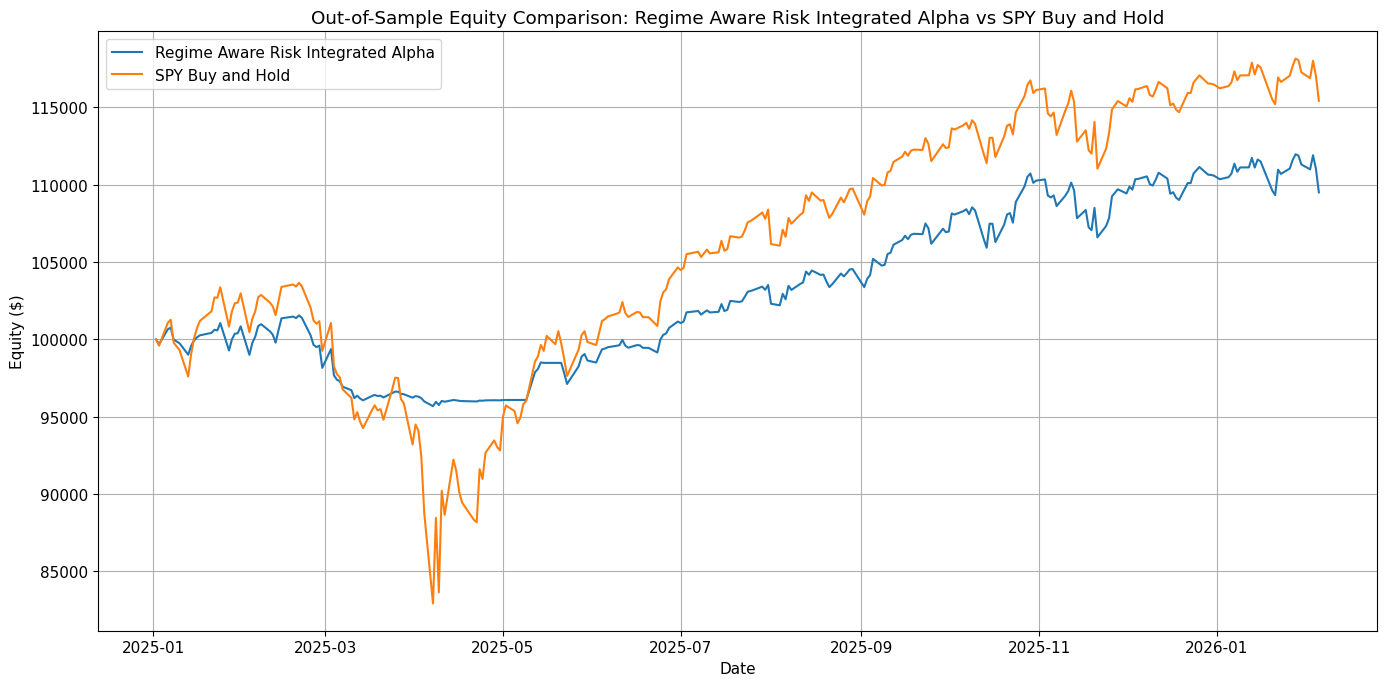

Saved figure: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\figures\phase_7_1_oos_100k_strategy_vs_spy_2025_2026.png


In [10]:
# ============================================
# Graph: Out-of-Sample Rebased Equity Comparison
# Period: 2025-01-01 to 2026-03-01
# Purpose:
# - Compare Regime Aware Risk Integrated Alpha vs SPY Buy and Hold
# - Force both series to start at $100,000 on 2025-01-01
# - Measure only out-of-sample live-period performance
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

INITIAL_COMPARISON_CAPITAL = 100000.0

# Load Phase 7.1 execution data if not already in memory
if "backtest_df" not in globals():
    PROJECT_ROOT = Path.cwd()
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

    phase_7_1_parquet = PROCESSED_DIR / "phase_7_1_execution_data.parquet"
    phase_7_1_csv = PROCESSED_DIR / "phase_7_1_execution_data.csv"

    if phase_7_1_parquet.exists():
        backtest_df = pd.read_parquet(phase_7_1_parquet)
    else:
        backtest_df = pd.read_csv(phase_7_1_csv, index_col=0, parse_dates=True)

    backtest_df.index = pd.to_datetime(backtest_df.index)
    backtest_df = backtest_df.sort_index()

# Define exact out-of-sample window
plot_start = pd.Timestamp("2025-01-01")
plot_end = pd.Timestamp("2026-03-01")

plot_df = backtest_df.loc[
    (backtest_df.index >= plot_start) &
    (backtest_df.index <= plot_end)
].copy()

if len(plot_df) == 0:
    raise ValueError("No rows found in the requested out-of-sample window.")

# Rebuild equity from returns so both start at $100,000 on the first day of the window
plot_df["strategy_equity_oos_rebased"] = INITIAL_COMPARISON_CAPITAL * (1.0 + plot_df["strategy_return"].fillna(0.0)).cumprod()
plot_df["buy_hold_equity_oos_rebased"] = INITIAL_COMPARISON_CAPITAL * (1.0 + plot_df["buy_hold_return"].fillna(0.0)).cumprod()

# Force the first row to exactly $100,000 for visual clarity
plot_df.iloc[0, plot_df.columns.get_loc("strategy_equity_oos_rebased")] = INITIAL_COMPARISON_CAPITAL
plot_df.iloc[0, plot_df.columns.get_loc("buy_hold_equity_oos_rebased")] = INITIAL_COMPARISON_CAPITAL

print("Out-of-sample rows:", len(plot_df))
print("Out-of-sample date range:", plot_df.index.min(), "to", plot_df.index.max())

print("\nFinal out-of-sample equity values:")
print("Regime Aware Risk Integrated Alpha:", round(float(plot_df["strategy_equity_oos_rebased"].iloc[-1]), 2))
print("SPY Buy and Hold:", round(float(plot_df["buy_hold_equity_oos_rebased"].iloc[-1]), 2))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(plot_df.index, plot_df["strategy_equity_oos_rebased"], label="Regime Aware Risk Integrated Alpha")
ax.plot(plot_df.index, plot_df["buy_hold_equity_oos_rebased"], label="SPY Buy and Hold")

ax.set_title("Out-of-Sample Equity Comparison: Regime Aware Risk Integrated Alpha vs SPY Buy and Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Equity ($)")
ax.legend()

fig.tight_layout()

PROJECT_ROOT = Path.cwd()
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

output_path = FIG_DIR / "phase_7_1_oos_100k_strategy_vs_spy_2025_2026.png"
fig.savefig(output_path, dpi=150)

plt.show()

print("Saved figure:", output_path)

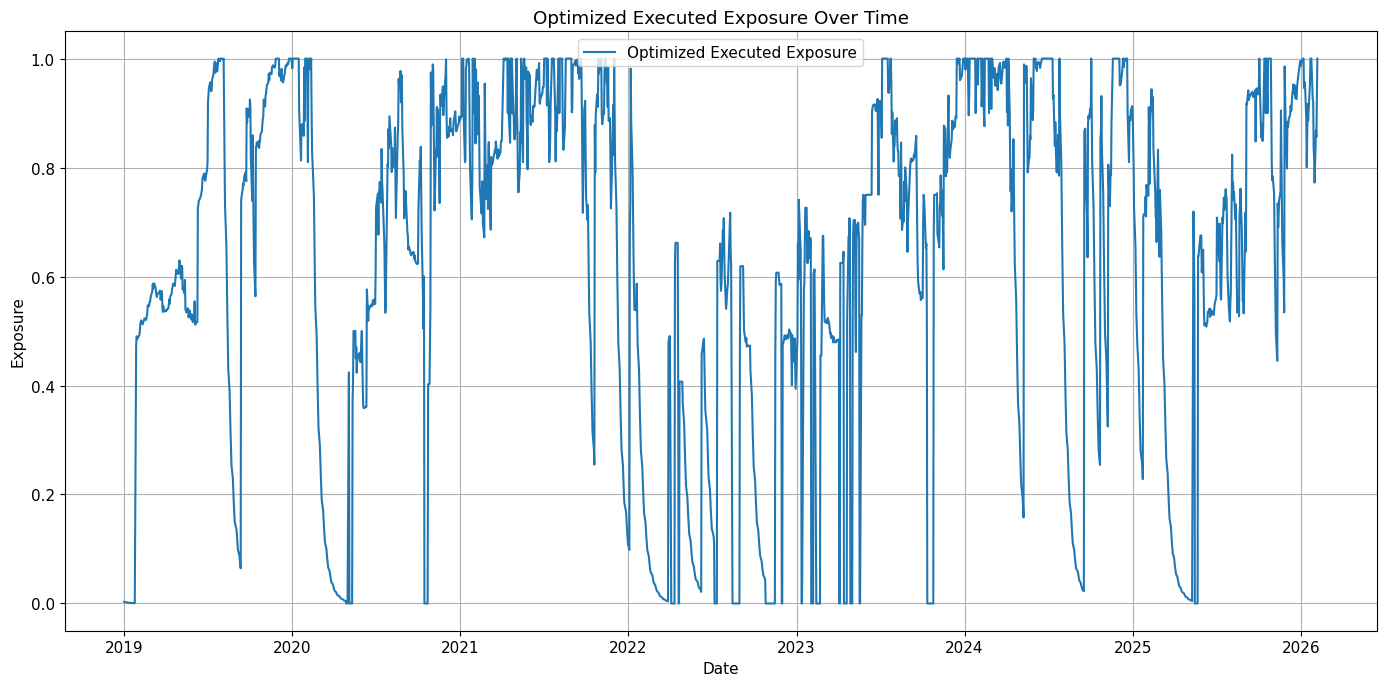

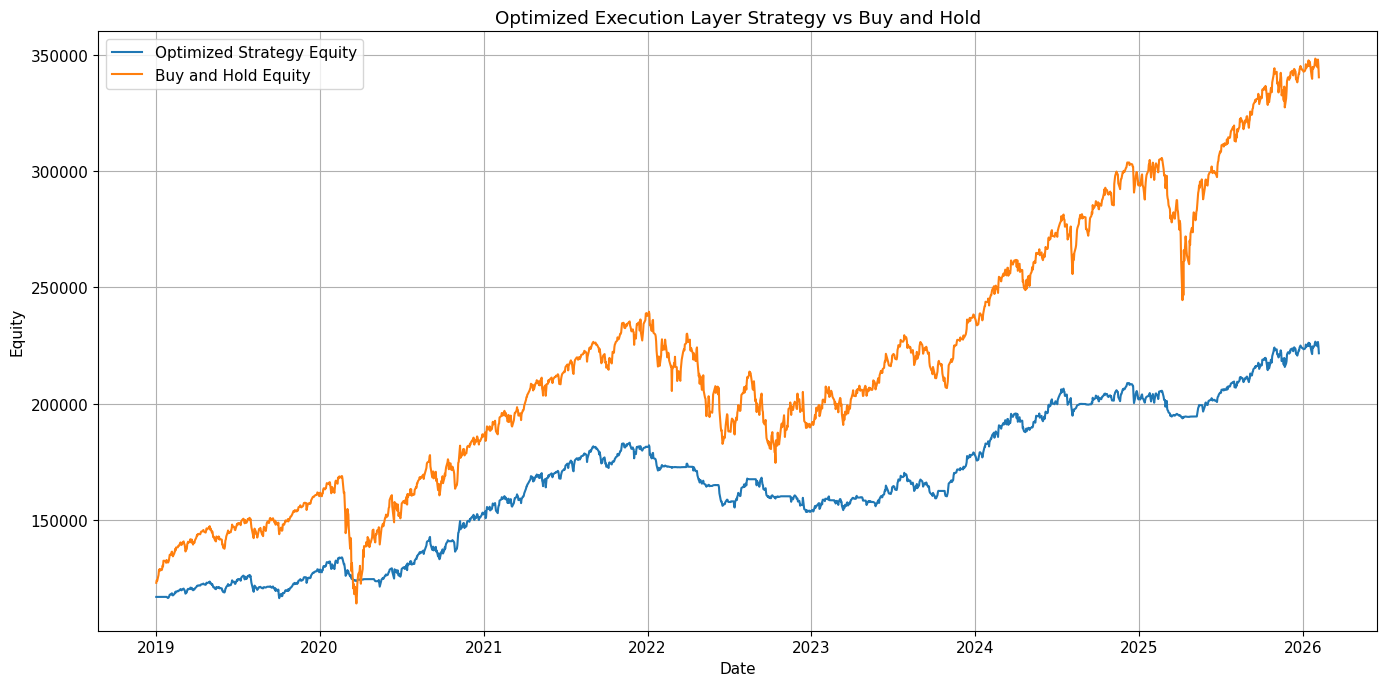

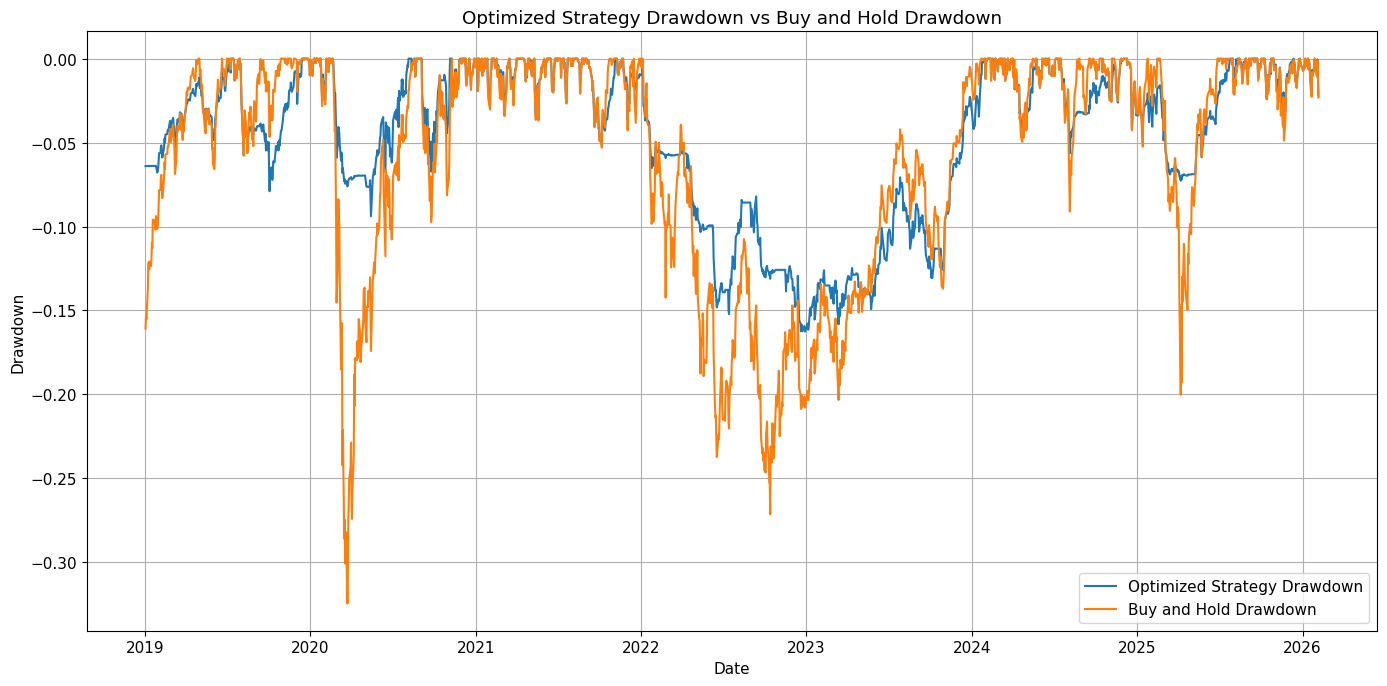

In [11]:
# ============================================
# Cell 10: Visualization of optimized exposure, equity, and drawdown
# Purpose:
# - Visually inspect the actual optimized executable strategy
# - Compare the optimized execution layer against buy-and-hold
# - Save formal figures for later reporting
# ============================================

plot_data = backtest_df.loc["2019-01-01":].copy()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["executed_exposure"], label="Optimized Executed Exposure")
ax.set_title("Optimized Executed Exposure Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Exposure")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_7_1_executed_exposure.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["strategy_equity"], label="Optimized Strategy Equity")
ax.plot(plot_data.index, plot_data["buy_hold_equity"], label="Buy and Hold Equity")
ax.set_title("Optimized Execution Layer Strategy vs Buy and Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Equity")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_7_1_strategy_vs_buy_hold.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["strategy_drawdown"], label="Optimized Strategy Drawdown")
ax.plot(plot_data.index, plot_data["buy_hold_drawdown"], label="Buy and Hold Drawdown")
ax.set_title("Optimized Strategy Drawdown vs Buy and Hold Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_7_1_drawdown_comparison.png", dpi=150)
plt.show()

In [12]:
# ============================================
# Cell 11: Save Phase 7.1 outputs for Phase 8 / 9 evaluation
# Purpose:
# - Persist the optimized execution and risk management layer outputs
# - Save metadata for later reporting
# - Maintain a stable notebook-to-notebook contract
# ============================================

phase_7_1_csv_path = PROCESSED_DIR / "phase_7_1_execution_data.csv"
phase_7_1_parquet_path = PROCESSED_DIR / "phase_7_1_execution_data.parquet"

backtest_df.to_csv(phase_7_1_csv_path, index=True)
print(f"Saved CSV: {phase_7_1_csv_path}")

try:
    backtest_df.to_parquet(phase_7_1_parquet_path, index=True)
    print(f"Saved Parquet: {phase_7_1_parquet_path}")
except Exception as e:
    print(f"Parquet save skipped: {e}")

phase_7_1_metadata = {
    "phase": "Phase 7.1 - Execution & Risk Management Layer (Optimized)",
    "source_notebook": "7.1 - Execution & Risk Management Layer (Optimized).ipynb",
    "initial_capital": float(INITIAL_CAPITAL),
    "slippage_bps": float(SLIPPAGE_BPS),
    "transaction_cost_bps": float(TRANSACTION_COST_BPS),
    "row_count": int(len(backtest_df)),
    "column_count": int(backtest_df.shape[1]),
    "avg_exposure": float(backtest_df["executed_exposure"].mean()),
    "final_strategy_equity": float(backtest_df["strategy_equity"].iloc[-1]),
    "final_buy_hold_equity": float(backtest_df["buy_hold_equity"].iloc[-1]),
    "max_strategy_drawdown": float(backtest_df["strategy_drawdown"].min()),
    "max_buy_hold_drawdown": float(backtest_df["buy_hold_drawdown"].min()),
    "start_date": str(backtest_df.index.min().date()),
    "end_date": str(backtest_df.index.max().date()),
}

phase_7_1_metadata_path = META_DIR / "phase_7_1_metadata.json"
with open(phase_7_1_metadata_path, "w", encoding="utf-8") as f:
    json.dump(phase_7_1_metadata, f, indent=4)

print(f"Saved metadata: {phase_7_1_metadata_path}")
print("Phase 7.1 output contract is ready for Phase 8 / 9 evaluation.")

Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_7_1_execution_data.csv
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_7_1_execution_data.parquet
Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_7_1_metadata.json
Phase 7.1 output contract is ready for Phase 8 / 9 evaluation.


In [13]:
# ============================================
# Cell 12: Loader snippet for evaluation
# Purpose:
# - Provide a stable loading pattern for later backtesting/evaluation notebooks
# - Keep notebook integration deterministic and easy to debug
# - Confirm the optimized execution handoff works
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

phase_7_1_parquet = PROCESSED_DIR / "phase_7_1_execution_data.parquet"
phase_7_1_csv = PROCESSED_DIR / "phase_7_1_execution_data.csv"

print("Looking for Phase 7.1 files:")
print("Parquet:", phase_7_1_parquet)
print("CSV:", phase_7_1_csv)

if phase_7_1_parquet.exists():
    phase_7_1_data = pd.read_parquet(phase_7_1_parquet)
    print("Loaded Parquet file")
elif phase_7_1_csv.exists():
    phase_7_1_data = pd.read_csv(phase_7_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 7.1 data file was not found. "
        f"Expected one of:\n{phase_7_1_parquet}\n{phase_7_1_csv}"
    )

phase_7_1_data.index = pd.to_datetime(phase_7_1_data.index)
phase_7_1_data = phase_7_1_data.sort_index()

print("\nLoaded Phase 7.1 dataset preview:")
print(phase_7_1_data.head())

Looking for Phase 7.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_7_1_execution_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_7_1_execution_data.csv
Loaded Parquet file

Loaded Phase 7.1 dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.380005  203.509995  204.059998     168.990479   
2015-02-05  204.860001  206.300003  204.770004  206.119995     170.696411   
2015-02-06  206.559998  207.240005  204.919998  205.550003     170.224442   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2015-02-

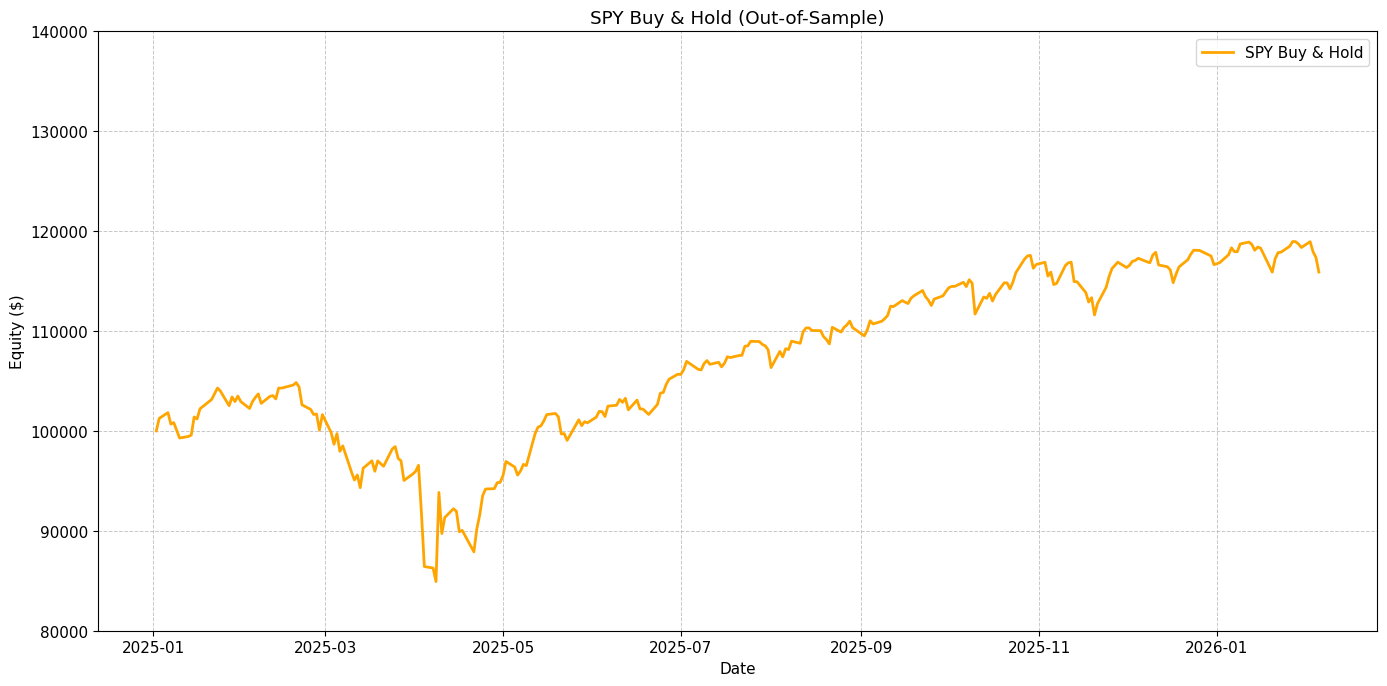

In [14]:
# ============================================
# Phase 7.1 - SPY Buy & Hold (Normalized)
# Purpose:
# - Load Phase 7.1 execution data if needed
# - Plot SPY Buy & Hold from 2025-01-01 to 2026-03-01
# - Normalize to 100,000
# - Fix y-axis to 85,000 through 130,000
# ============================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Load execution data if exec_df is not already defined
if "exec_df" not in globals():
    PROJECT_ROOT = Path.cwd()
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

    parquet_path = PROCESSED_DIR / "phase_7_1_execution_data.parquet"
    csv_path = PROCESSED_DIR / "phase_7_1_execution_data.csv"

    if parquet_path.exists():
        exec_df = pd.read_parquet(parquet_path)
    elif csv_path.exists():
        exec_df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    else:
        raise FileNotFoundError(
            "Phase 7.1 execution data not found. "
            f"Expected one of:\n{parquet_path}\n{csv_path}"
        )

    exec_df.index = pd.to_datetime(exec_df.index)
    exec_df = exec_df.sort_index()

# Out-of-sample window
oos_df = exec_df.loc["2025-01-01":"2026-03-01"].copy()

# Compute SPY returns
oos_df["spy_return"] = oos_df["spy_close"].pct_change().fillna(0.0)

# Normalize to 100k
initial_capital = 100000
oos_df["spy_equity_norm"] = (1.0 + oos_df["spy_return"]).cumprod() * initial_capital

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    oos_df.index,
    oos_df["spy_equity_norm"],
    linewidth=2,
    label="SPY Buy & Hold",
    color="orange"
)

ax.set_ylim(80000, 140000)

# ✅ Add grid (aligned + clean)
ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.7)

ax.set_title("SPY Buy & Hold (Out-of-Sample)")
ax.set_xlabel("Date")
ax.set_ylabel("Equity ($)")
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# Phase 7.1 - Regime Aware Risk Integrated Alpha (Normalized)
# Purpose:
# - Load Phase 7.1 execution data if needed
# - Plot strategy equity from 2025-01-01 to 2026-03-01
# - Normalize to 100,000
# - Fix y-axis to 85,000 through 130,000
# ============================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Load execution data if exec_df is not already defined
if "exec_df" not in globals():
    PROJECT_ROOT = Path.cwd()
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

    parquet_path = PROCESSED_DIR / "phase_7_1_execution_data.parquet"
    csv_path = PROCESSED_DIR / "phase_7_1_execution_data.csv"

    if parquet_path.exists():
        exec_df = pd.read_parquet(parquet_path)
    elif csv_path.exists():
        exec_df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    else:
        raise FileNotFoundError(
            "Phase 7.1 execution data not found. "
            f"Expected one of:\n{parquet_path}\n{csv_path}"
        )

    exec_df.index = pd.to_datetime(exec_df.index)
    exec_df = exec_df.sort_index()

# Out-of-sample window
oos_df = exec_df.loc["2025-01-01":"2026-03-01"].copy()

# Normalize strategy to 100k using strategy returns
initial_capital = 100000
oos_df["strategy_equity_norm"] = (1.0 + oos_df["strategy_return"].fillna(0.0)).cumprod() * initial_capital

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    oos_df.index,
    oos_df["strategy_equity_norm"],
    linewidth=2,
    label="Regime Aware Risk Integrated Alpha"
)

ax.set_ylim(95000, 115000)
ax.set_title("Regime Aware Risk Integrated Alpha (Out-of-Sample)")
ax.set_xlabel("Date")
ax.set_ylabel("Equity ($)")
ax.legend()

plt.tight_layout()
plt.show()

KeyError: 'strategy_return'